
# Intoxicants Expenditure Analysis

This notebook estimates **monthly household spending on intoxicants** for the full population.

- **Population**: all households in the sample.
- **Treatment**: household is treated if it is either:
  - a PMJAY household member (`is_hhmem_pmjay == 1`), or
  - has received benefits under state/centrally sponsored health insurance schemes (`is_benefit_healthscheme == 1`).
- **Outcome**: item-wise intoxicants expenditure from Section 12 consumption files.
- **Period conversion**: weekly spending is converted to monthly spending using `monthly = weekly * (30/7)`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hces

In [2]:

INTOXICANT_ITEMS = {
    300: "pan leaf",
    301: "pan finished",
    302: "ingredients for pan",
    310: "bidi",
    311: "cigarettes",
    312: "leaf tobacco",
    313: "snuff",
    314: "hookah tobacco",
    315: "cheroot",
    316: "gutka/zarda/kimam/surti",
    317: "other tobacco products",
    320: "ganja",
    321: "toddy",
    322: "country liquor",
    323: "beer",
    324: "foreign liquor/wine",
    325: "other intoxicants",
}

idf = pd.read_parquet("../../hces-2023-24/data/sec-12.1-CSQ.parquet")['cons_total_value'].unstack()
idf = pd.concat([idf, pd.read_parquet("../../hces-2023-24/data/sec-12.2-CSQ.parquet")['cons_total_value'].unstack()], axis=1, verify_integrity=True)
idf = pd.concat([idf, pd.read_parquet("../../hces-2023-24/data/sec-12.3-CSQ.parquet")['cons_total_value'].unstack()], axis=1, verify_integrity=True)
idf = idf.fillna(0)[INTOXICANT_ITEMS.keys()]
df = hces.load()
ix = df.index.intersection(idf.index)

df = df.loc[ix]
idf = idf.loc[ix]

df = pd.concat([df, idf], axis=1)

In [6]:
xdf = df.copy()
xdf['treat'] = (xdf['is_benefit_healthscheme'] == 1) | (xdf['is_hhmem_pmjay'] == 1)

psm = hces.propensity_score_match(
        xdf,
        num_cols=["family_size", "n_children", "n_elderly"],
        cat_cols=[
            "sector",
            "nss_region",
            "employed_annual",
            "max_income_from",
            "hoh_religion",
            "caste",
        ],
    )
psm = psm[psm["label"].isin(["D", "E"])]
cols = list(INTOXICANT_ITEMS.keys())
psm[cols] /= (psm['family_size'] - psm['n_children']).values.reshape(-1, 1)

In [22]:
intox = hces.compare(psm, ['sector', 'treat'], cols)
intox = intox.xs(level=1, key=True)  - intox.xs(level=1, key=False)
intox = intox.rename(INTOXICANT_ITEMS, axis=1) * 52 / 12

In [23]:
intox

,pan leaf,pan finished,ingredients for pan,bidi,cigarettes,leaf tobacco,snuff,hookah tobacco,cheroot,gutka/zarda/kimam/surti,other tobacco products,ganja,toddy,country liquor,beer,foreign liquor/wine,other intoxicants
sector,,,,,,,,,,,,,,,,,
rural,0.012231,-4.997271,4.457254,12.606648,2.316387,-2.755196,-0.138202,-0.613911,0.399160,-3.510451,-4.826052,-0.212444,-2.154611,12.701506,-2.903732,-9.905665,-0.246467
urban,-4.271495,-2.173172,-2.435403,5.088264,-2.187623,0.670108,-0.038312,-0.490655,1.208658,1.862707,-7.267635,0.031013,1.672220,10.365054,-13.898824,-7.956563,6.429894


In [24]:
intox['Paan'] = intox.pop('pan leaf') + intox.pop('pan finished') + intox.pop('ingredients for pan')
intox['Gutkha'] = intox.pop('gutka/zarda/kimam/surti')
intox.columns = [c.title() for c in intox.columns]
intox.drop(['Snuff', 'Cheroot', 'Ganja', 'Hookah Tobacco'], axis=1, inplace=True)

In [25]:
import matplotlib.font_manager as fm

fm.fontManager.addfont('/home/jaidevd/.local/share/fonts/Lora-Bold.ttf')
fm.fontManager.addfont('/home/jaidevd/.local/share/fonts/Lora-Regular.ttf')

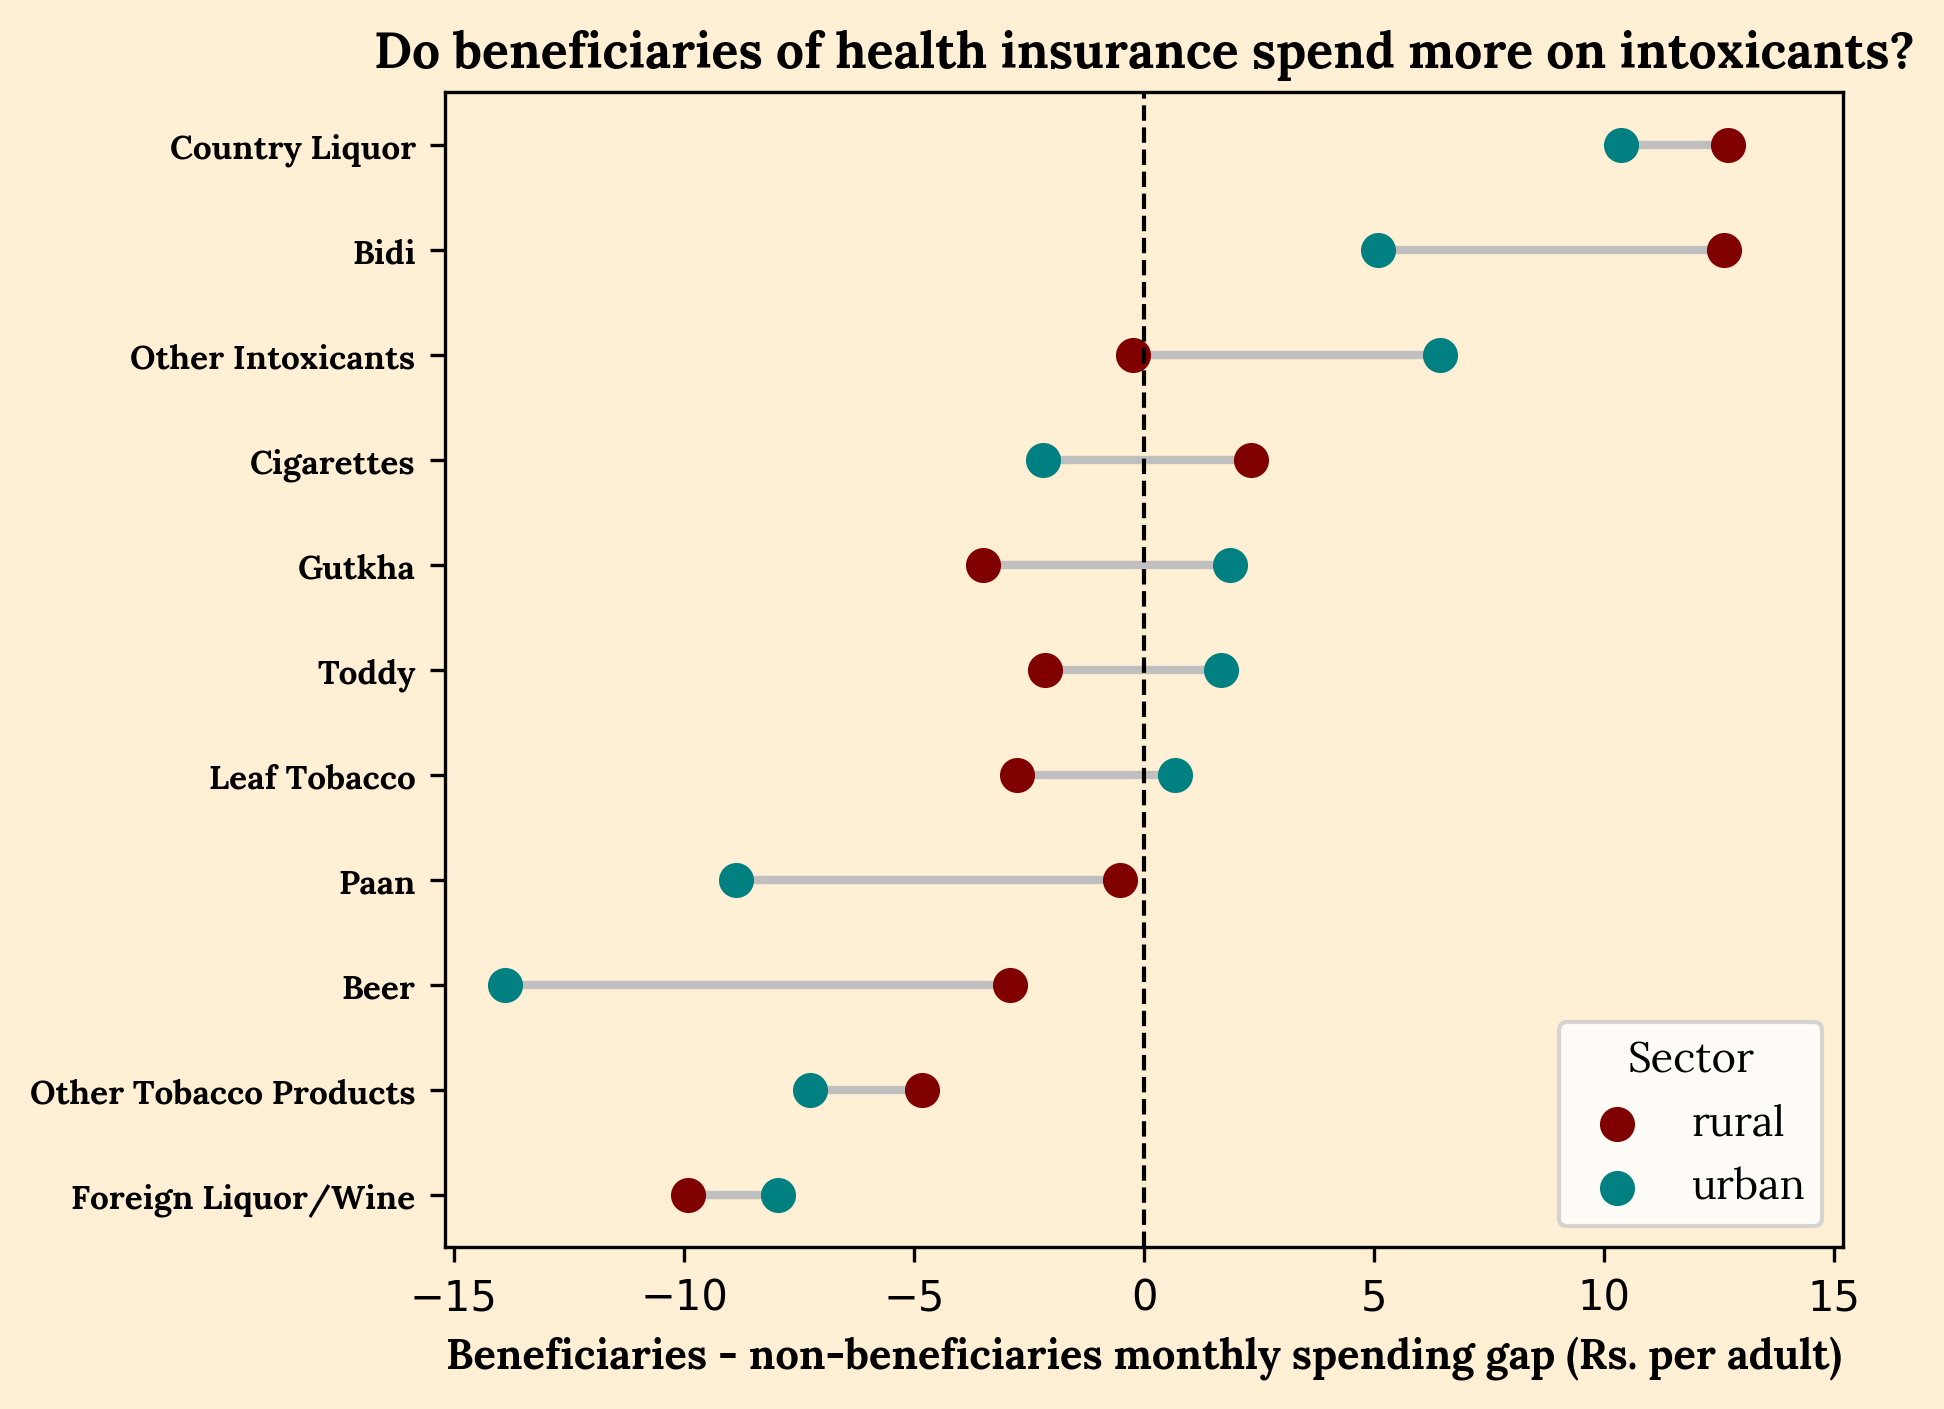

In [39]:
# Range chart of treatment-control spending gap by sector
plot_df = intox.T.copy()
plot_df.columns = plot_df.columns.astype(str)

if plot_df.shape[1] < 2:
    raise ValueError("Range chart needs at least two sector columns in `intox`.")

ordered_items = plot_df.max(axis=1).sort_values(ascending=True).index
plot_df = plot_df.loc[ordered_items]

y = range(len(plot_df))
min_vals = plot_df.min(axis=1)
max_vals = plot_df.max(axis=1)

fig, ax = plt.subplots(dpi=300)
ax.hlines(y, min_vals, max_vals, color="0.75", lw=2, zorder=1)

colors = ["maroon", "teal"]
for i, col in enumerate(plot_df.columns):
    color = colors[i] if i < len(colors) else "0.35"
    ax.scatter(plot_df[col], y, s=55, color=color, label=col, zorder=2)

ax.axvline(0, color="black", lw=1, ls="--")
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df.index, fontfamily="Lora", fontweight='bold', fontsize=8)
ax.set_xlabel("Beneficiaries - non-beneficiaries monthly spending gap (Rs. per adult)", fontfamily="Lora", fontweight="bold")
ax.set_title("Do beneficiaries of health insurance spend more on intoxicants?", fontfamily="Lora", fontweight="bold")
ax.legend(title="Sector", prop=dict(family="Lora"), title_fontproperties=dict(family="Lora"), loc='lower right')

ax.set_xlim(-15.2, 15.2)
ax.set_facecolor('papayawhip')
fig.set_facecolor('papayawhip')
plt.tight_layout()


